In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load dataset without internet
iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Done! Dataset loaded!")
print(f"Shape: {df.shape}")
print()
print(df.head())

Done! Dataset loaded!
Shape: (150, 5)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [2]:
# Check data info and statistics
print("--- Dataset Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Species Count ---")
print(df['species'].value_counts())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB

--- Descriptive Statistics ---
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.

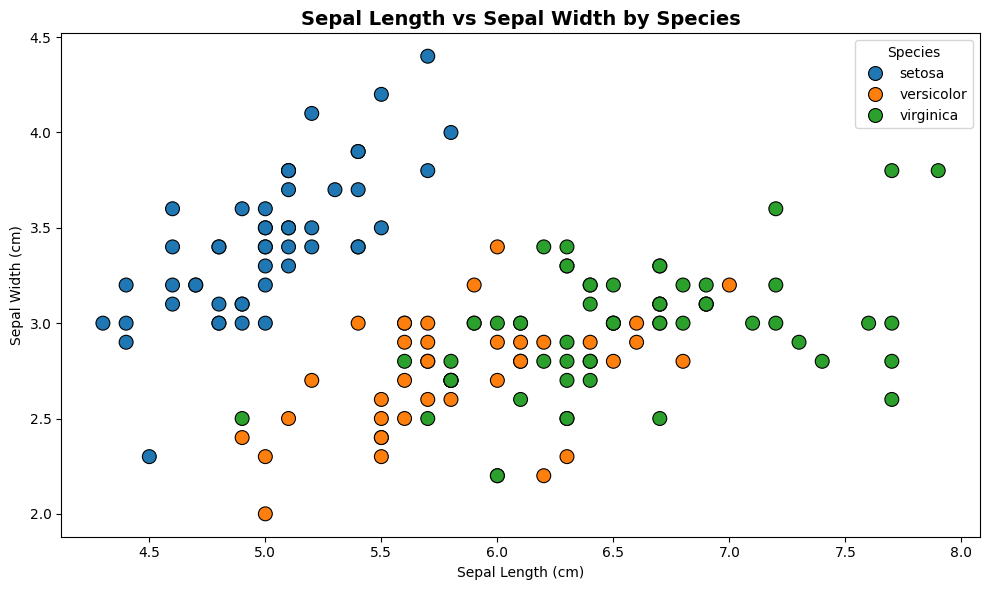

In [3]:
# Scatter Plot - Sepal Length vs Sepal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species',
    s=100,
    edgecolor='black'
)
plt.title('Sepal Length vs Sepal Width by Species', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

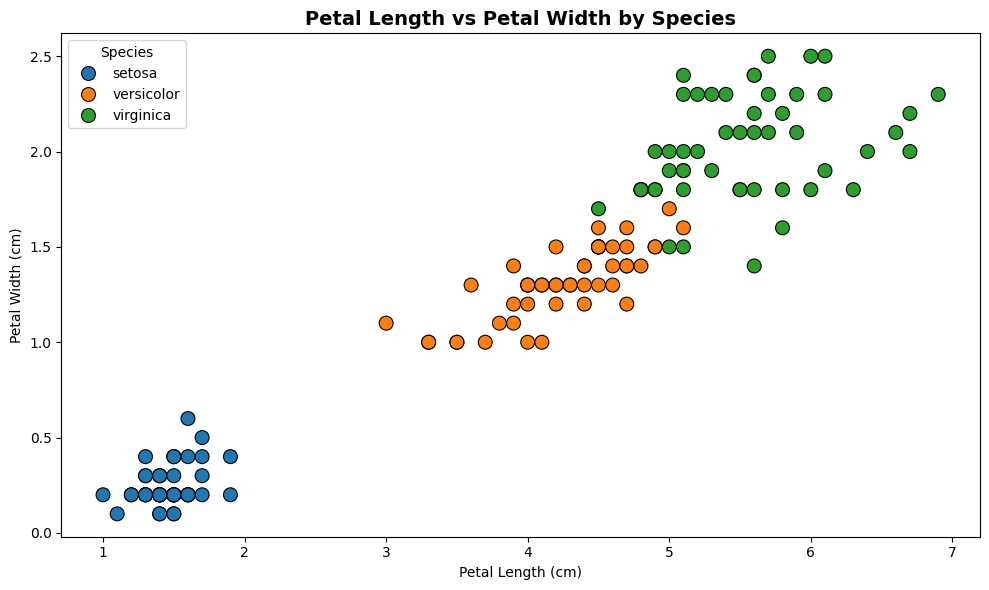

In [4]:
# Scatter Plot - Petal Length vs Petal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    s=100,
    edgecolor='black'
)
plt.title('Petal Length vs Petal Width by Species', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

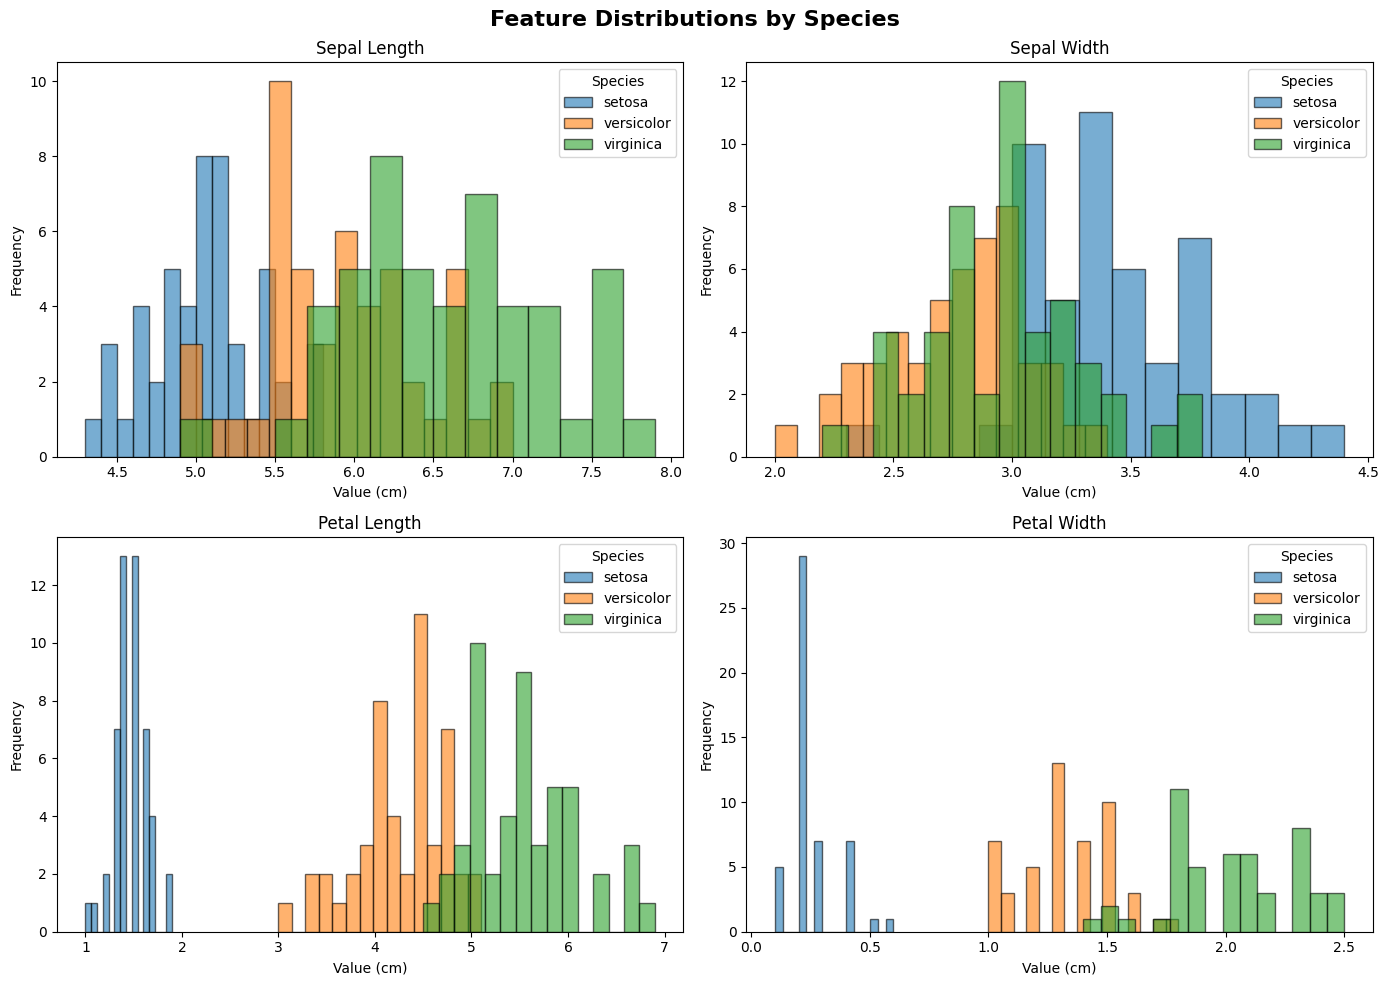

In [5]:
# Histogram - Distribution of all 4 features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold')

for ax, feature in zip(axes.flatten(), features):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[feature], bins=15, alpha=0.6, label=species, edgecolor='black')
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Frequency')
    ax.legend(title='Species')

plt.tight_layout()
plt.show()

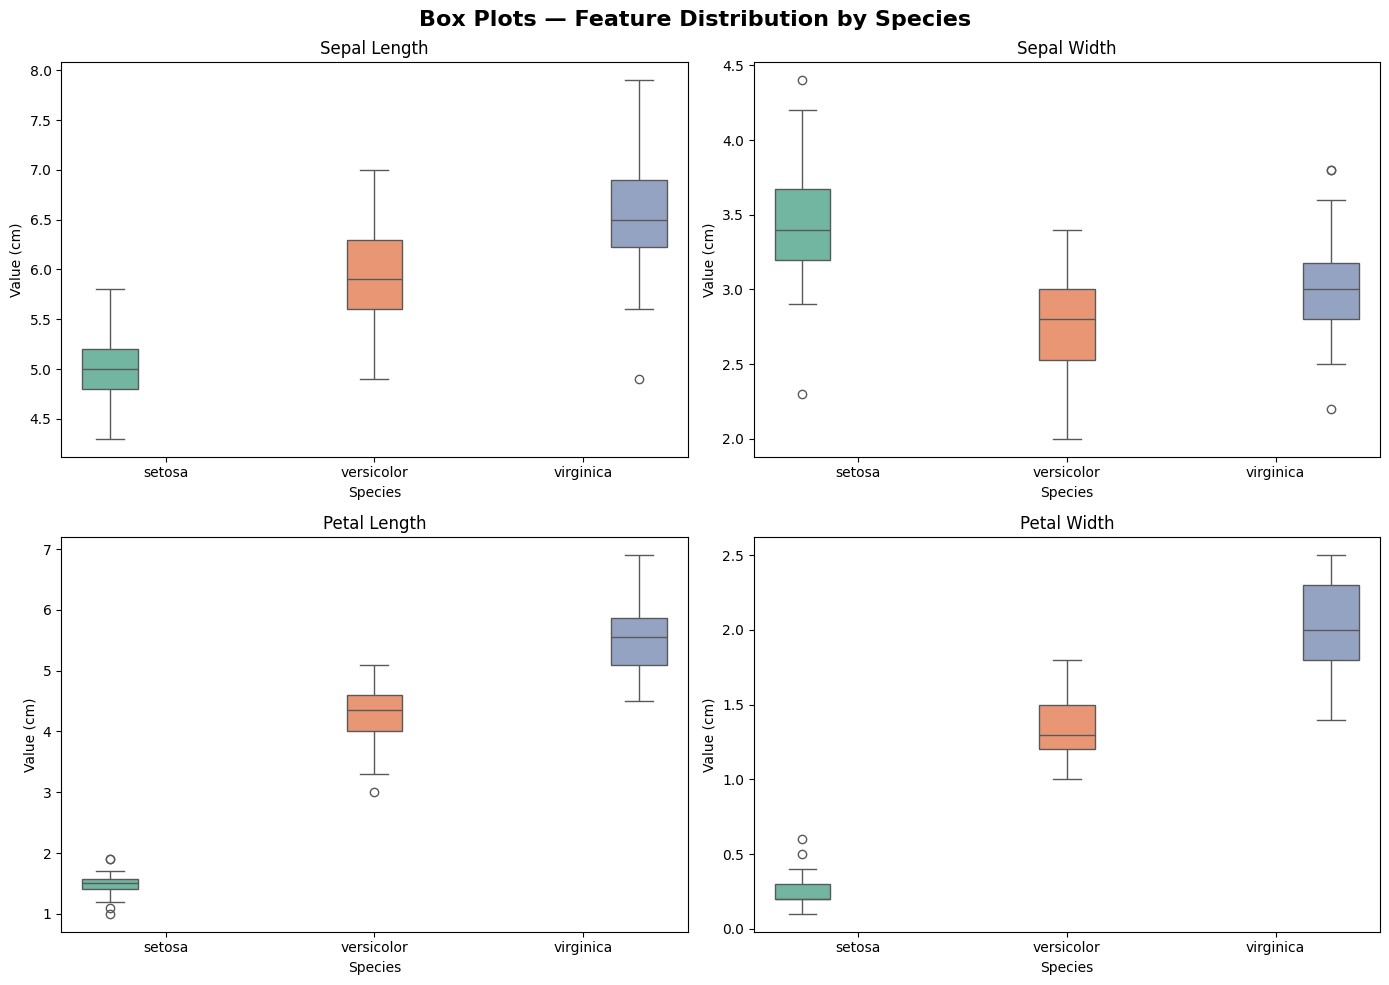

In [7]:
# Corrected Box Plot Code
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the 'features' list (the names of your numerical columns)
# Adjust these names if your DataFrame columns are named differently
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 2. Set up the figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Box Plots — Feature Distribution by Species', fontsize=16, fontweight='bold')

# 3. Loop through and plot each feature
for ax, feature in zip(axes.flatten(), features):
    # Added hue='species' and legend=False to avoid future warnings
    sns.boxplot(data=df, x='species', y=feature, ax=ax, hue='species', palette='Set2', legend=False)
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Species')
    ax.set_ylabel('Value (cm)')
   
plt.tight_layout()
plt.show()

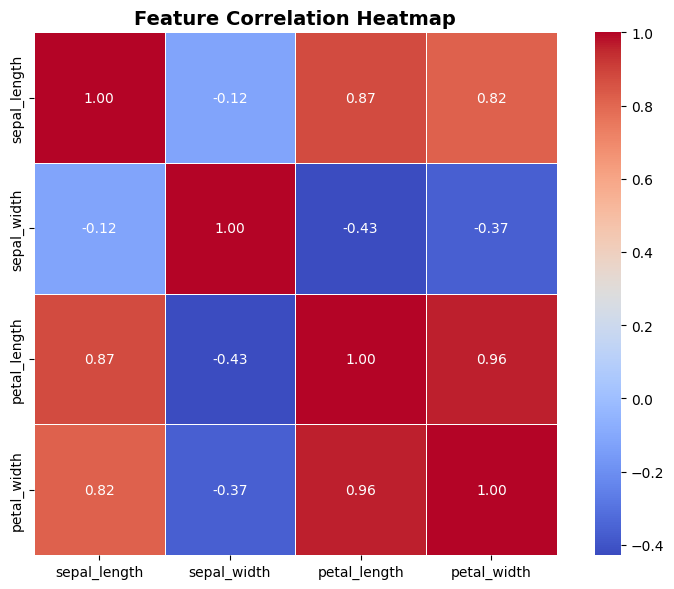

In [7]:
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\SA.NET\AppData\Local\Temp\ipykernel_2920\2580481163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',
C:\Users\SA.NET\AppData\Local\Temp\ipykernel_2920\2580481163.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_width',


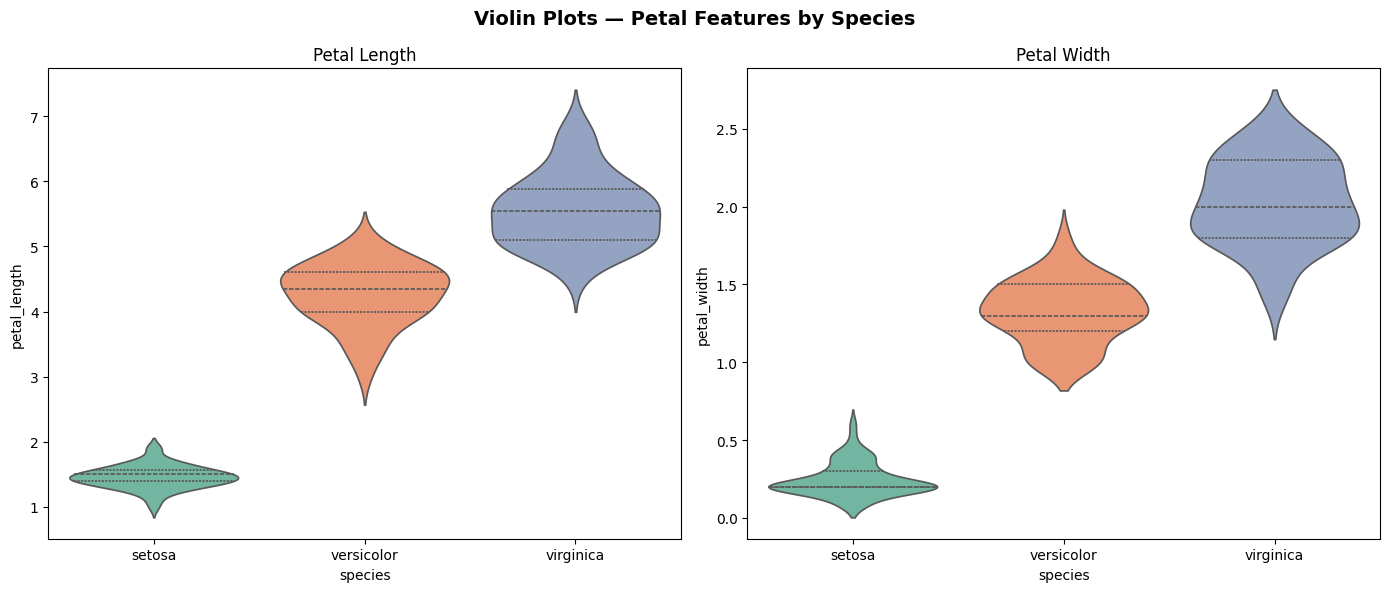

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Violin Plots — Petal Features by Species', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='species', y='petal_length',
               ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('Petal Length')

sns.violinplot(data=df, x='species', y='petal_width',
               ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title('Petal Width')

plt.tight_layout()
plt.show()

In [4]:
print("       FINAL INSIGHTS — IRIS DATASET")


print("\n Mean Values by Species ")
print(df.groupby('species').mean().round(2))

print("\n Key Findings:")
print("1. No missing values — dataset is clean")
print("2. Setosa is clearly separable from others")
print("3. Petal features are better for classification")
print("4. Strong correlation between petal length & width")
print("5. 50 samples per species — perfectly balanced")


       FINAL INSIGHTS — IRIS DATASET

 Mean Values by Species 
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.43          1.46         0.25
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03

 Key Findings:
1. No missing values — dataset is clean
2. Setosa is clearly separable from others
3. Petal features are better for classification
4. Strong correlation between petal length & width
5. 50 samples per species — perfectly balanced
